Eigenvectors are special: their direction doesn't change under the transformation

Eigenvalues are how much they're stretched/compressed

# Eigenvectors keep their direction when a transformation (matrix) is applied. Only their length (magnitude) may change — not their angle.

# Normal Vectors:
    
When you apply a matrix to most vectors, they:
rotate
stretch/shrink
even flip sometimes

→ Direction changes


# Eigenvectors:
When you apply the matrix A to an eigenvector v, it becomes:
    
A⋅v=λ⋅v

That means:
    
The output is just a scaled version of the same vector.
It’s pointing exactly in the same (or opposite) direction.

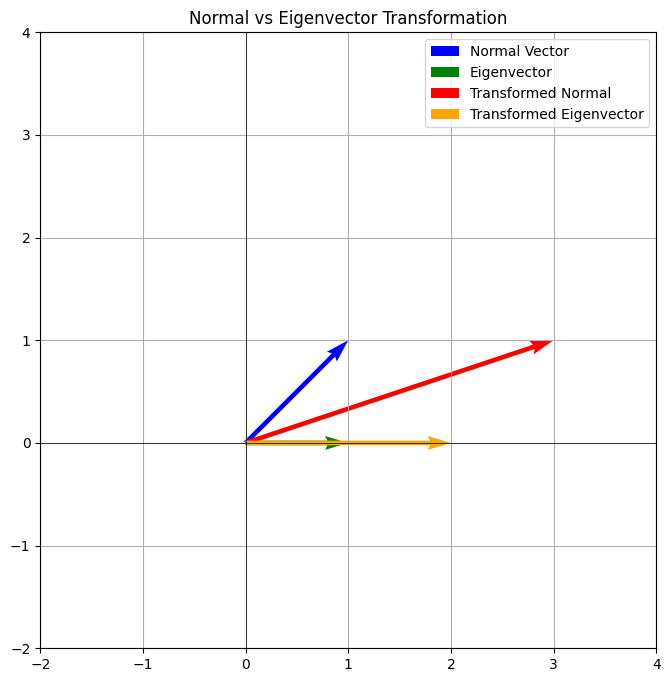

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define a linear transformation matrix (shear)
A = np.array([
    [2, 1],
    [0, 1]
])

# Arbitrary "normal" vector (not an eigenvector)
v_normal = np.array([1, 1])

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

# Pick the first eigenvector
v_eigen = eigenvectors[:, 0]

# Transform both vectors
v_normal_trans = A @ v_normal
v_eigen_trans = A @ v_eigen

# Plot original and transformed vectors
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the original vectors (blue/green)
ax.quiver(0, 0, v_normal[0], v_normal[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Normal Vector')
ax.quiver(0, 0, v_eigen[0], v_eigen[1], angles='xy', scale_units='xy', scale=1, color='green', label='Eigenvector')

# Plot the transformed vectors (red/orange)
ax.quiver(0, 0, v_normal_trans[0], v_normal_trans[1], angles='xy', scale_units='xy', scale=1, color='red', label='Transformed Normal')
ax.quiver(0, 0, v_eigen_trans[0], v_eigen_trans[1], angles='xy', scale_units='xy', scale=1, color='orange', label='Transformed Eigenvector')

# Plot settings
ax.set_xlim(-2, 4)
ax.set_ylim(-2, 4)
ax.set_aspect('equal')
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title("Normal vs Eigenvector Transformation")
ax.legend()
plt.show()



Blue: original normal vector

Green: original eigenvector

Red: transformed normal vector (points somewhere else)

Orange: transformed eigenvector (stays in the same direction

v [1. 0.]
v [-1.00000000e+00  2.22044605e-16]


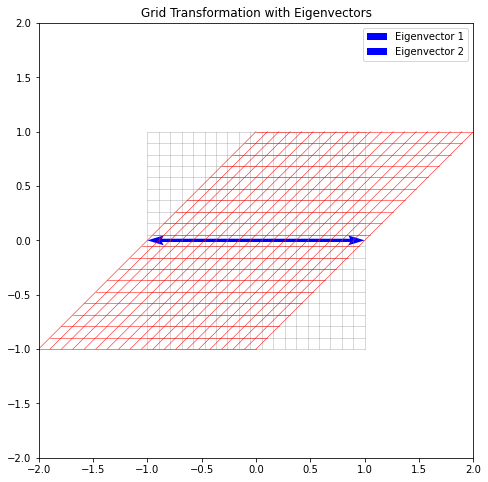

In [ ]:
# Shear Transformation

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image
img_path = "image4.jpeg"
image = Image.open(img_path)

# Matrix A (a simple shear transformation)
A = np.array([[1, 1],
              [0, 1]])

# Eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

# Grid setup
grid_range = np.linspace(-1, 1, 20)
grid_points = np.array([[x, y] for x in grid_range for y in grid_range])

# Apply transformation to grid points
transformed_points = np.dot(grid_points, A.T)

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Show image in background
# ax.imshow(image, extent=[-2, 2, -2, 2], alpha=0.5)

# Plot original grid
for x in grid_range:
    ax.plot([x]*len(grid_range), grid_range, color='gray', lw=0.5, alpha=0.6)
for y in grid_range:
    ax.plot(grid_range, [y]*len(grid_range), color='gray', lw=0.5, alpha=0.6)

# Plot transformed grid
for x in grid_range:
    line = np.array([[x, y] for y in grid_range])
    transformed_line = A @ line.T
    ax.plot(transformed_line[0], transformed_line[1], color='red', lw=0.5)

for y in grid_range:
    line = np.array([[x, y] for x in grid_range])
    transformed_line = A @ line.T
    ax.plot(transformed_line[0], transformed_line[1], color='red', lw=0.5)

# Plot eigenvectors
origin = np.array([0, 0])
for i in range(2):
    v = eigvecs[:, i]
    print('v',v)
    ax.quiver(*origin, *v, color='blue', scale=1, scale_units='xy', angles='xy', label=f"Eigenvector {i+1}")

ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.grid(False)
ax.legend()
plt.title("Grid Transformation with Eigenvectors")
plt.show()

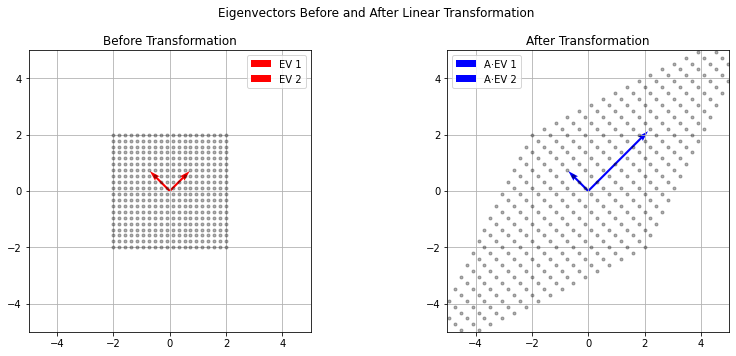

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define transformation matrix
A = np.array([[2, 1],
              [1, 2]])

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

# Grid setup
grid_range = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(grid_range, grid_range)
points = np.vstack([X.ravel(), Y.ravel()])

# Transform the grid points
transformed_points = A @ points

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
titles = ["Before Transformation", "After Transformation"]

for i, ax in enumerate(axs):
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_title(titles[i])

# Plot original grid and eigenvectors
axs[0].plot(points[0], points[1], 'k.', alpha=0.3)
for i in range(len(eigvals)):
    vec = eigvecs[:, i]
    axs[0].quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy',
                  scale=1, color='r', label=f"EV {i+1}")

# Plot transformed grid and transformed eigenvectors
axs[1].plot(transformed_points[0], transformed_points[1], 'k.', alpha=0.3)
for i in range(len(eigvals)):
    vec = eigvecs[:, i]
    tvec = A @ vec
    axs[1].quiver(0, 0, tvec[0], tvec[1], angles='xy', scale_units='xy',
                  scale=1, color='b', label=f"A·EV {i+1}")

axs[0].legend()
axs[1].legend()

plt.suptitle("Eigenvectors Before and After Linear Transformation")
plt.tight_layout()
plt.show()


# PCA

In [ ]:
“Imagine you have a lot of variables (features), and many of them are telling you almost the same thing. 
PCA helps you compress the information into fewer dimensions while keeping the most important patterns.”

simple analogy:

Photo compression → reduce file size but keep clarity
Packing luggage → keep essentials, remove redundancy

In [ ]:
Core Idea

PCA finds new axes (directions) in the data
These axes are called Principal Components

Each component:
    Captures maximum variance
    Is independent (uncorrelated) from others

In short:
“PCA rotates your data to find the most informative view.”

In [ ]:
Why PCA is useful ? 

Reduces number of variables (dimensionality reduction)
Removes redundancy (correlated features)
Speeds up models
Helps visualize complex data (2D/3D)
Reduces noise

In [ ]:
# Domain-specific examples 

Chemistry / Drug Discovery
•	Many molecular descriptors (100s–1000s features) 
•	PCA helps: 
o	Identify key chemical patterns 
o	Reduce feature space before modeling 
o	Visualize molecule clusters 
 Example: “Instead of 500 molecular features, PCA may reduce it to 10 meaningful components.”

AI / Machine Learning
•	High-dimensional datasets 
•	PCA helps: 
o	Preprocessing before models 
o	Avoid overfitting 
o	Speed up training 
Example: Face recognition → reduce pixel features

Healthcare / Biomedical
•	Patient data: vitals, tests, biomarkers 
•	PCA helps: 
o	Identify dominant health factors 
o	Detect patterns in diseases 
o	Reduce noisy measurements 
Example: Combine multiple test results into “health indices”

Business / Finance
•	Sales, customer behavior, metrics 
•	PCA helps: 
o	Customer segmentation 
o	Identify key drivers of revenue 
o	Reduce dashboard complexity 
Example: “Customer behavior” → reduced to 2–3 main patterns

Sports Analytics
•	Many variables: speed, angle, position, reaction time 
•	PCA helps: 
o	Identify key performance factors 
o	Reduce tracking data complexity 
 Example: “Player performance” → summarized into core dimensions

Cognitive / Eye Tracking 
•	Huge time-series gaze data 
•	PCA helps: 
o	Extract dominant gaze patterns 
o	Reduce noise 
o	Understand attention behavior 


In [ ]:
NOTE :

PCA is not feature selection → it creates new features
Components are linear combinations
PCA works best when relationships are linear

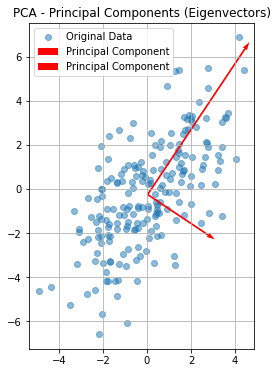

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Generate 2D synthetic data
np.random.seed(0)
X = np.dot(np.random.randn(2, 2), np.random.randn(2, 200)).T

# Applying PCA
pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[:, 0], X[:, 1], alpha=0.5, label='Original Data')

# Plot the eigenvectors (principal components)
origin = np.mean(X, axis=0)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    ax.quiver(*origin, *v, angles='xy', scale_units='xy', scale=1, color='red', label='Principal Component')

ax.set_aspect('equal')
ax.grid(True)
ax.legend()
plt.title("PCA - Principal Components (Eigenvectors)")
plt.show()


In [ ]:
# The red arrows are the eigenvectors (principal components).
# They point in the direction of maximum variance.
# The data cloud is stretched along those directions.
# PCA rotates the axes but does not change the relative direction of those components.

eig_vals [2.65599634 1.37582076]
eig_vals [[-0.87507302  0.48399092]
 [-0.48399092 -0.87507302]]


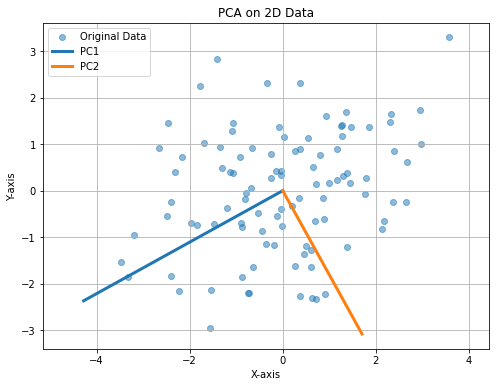

In [ ]:
# calculating PCA from scratch
import numpy as np
import matplotlib.pyplot as plt

# Generate 2D data
np.random.seed(42)
mean = [0, 0]
cov = [[3, 1], [1, 2]]  # Covariance matrix
X = np.random.multivariate_normal(mean, cov, 100)

# Center the data
X_centered = X - np.mean(X, axis=0)

# Compute the covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

# Compute eigenvalues and eigenvectors
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)


# Sort eigenvalues and eigenvectors
sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_indices]
eig_vecs = eig_vecs[:, sorted_indices]


print('eig_vals',eig_vals)
print('eig_vals',eig_vecs)


# Project data onto principal components
X_pca = X_centered @ eig_vecs

# Plot original data and principal components
plt.figure(figsize=(8, 6))
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5, label="Original Data")
for i in range(2):
    vec = eig_vecs[:, i] * np.sqrt(eig_vals[i]) * 3  # scale for visibility
    plt.plot([0, vec[0]], [0, vec[1]], linewidth=3, label=f"PC{i+1}")
plt.axis('equal')
plt.title("PCA on 2D Data")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.grid(True)
plt.show()


[2.65599634 1.37582076]
These are the eigenvalues of the covariance matrix which we got, and
they tell us how much variance there is in the data along each principal component (direction).

2.65599634 → variance along the first principal component (most important direction)

1.37582076 → variance along the second principal component

So, the first component explains more variance than the second — and PCA will prefer that direction when reducing dimensionality.

[[-0.87507302  0.48399092]
 [-0.48399092 -0.87507302]]


Each column here is a principal component direction (i.e., eigenvector):

Each vector tells you the direction in feature space (X1, X2) of a principal component.
The first eigenvector (PC1) points in the direction of maximum variance (matching the largest eigenvalue).
The second eigenvector (PC2) is orthogonal to the first and points in the next most significant variance direction.
These vectors are unit vectors — they have a magnitude of 1 and define the new axes.

Eigenvalues (explained variance): [2.65599634 1.37582076]
Eigenvectors (principal axes):
 [[ 0.87507302  0.48399092]
 [-0.48399092  0.87507302]]


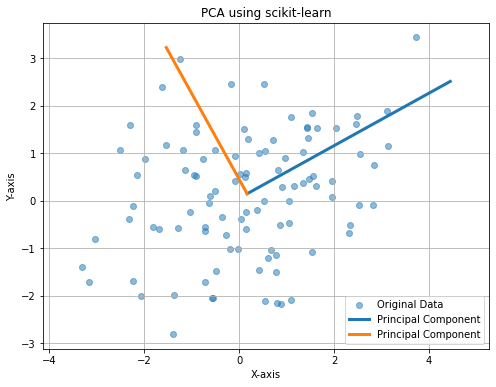

In [ ]:
# Inbuilt function
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Generate the same 2D data
np.random.seed(42)
mean = [0, 0]
cov = [[3, 1], [1, 2]]
X = np.random.multivariate_normal(mean, cov, 100)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Get components and explained variance
components = pca.components_         # eigenvectors
explained_variance = pca.explained_variance_  # eigenvalues

print("Eigenvalues (explained variance):", explained_variance)
print("Eigenvectors (principal axes):\n", components)

# Plot original data and PCA components
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label="Original Data")

origin = np.mean(X, axis=0)
for length, vector in zip(explained_variance, components):
    v = vector * 3 * np.sqrt(length)  # scale for visibility
    plt.plot([origin[0], origin[0] + v[0]],
             [origin[1], origin[1] + v[1]],
             linewidth=3, label="Principal Component")

plt.axis('equal')
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("PCA using scikit-learn")
plt.grid(True)
plt.legend()
plt.show()


# Both point in the same line/direction
# — just opposite directions on that line. For PCA,
# since we look into the direction (axis of variance), not the orientation, both are equivalent.

Eigenvectors from PCA can point in either direction, and both are equally valid. The orientation (sign) doesn’t affect how PCA works or how the data is projected — it’s the axis of variance that matters

In [ ]:
#1. What an eigenvector represents in PCA
In Principal Component Analysis, an eigenvector is:
A direction (axis) in space along which the data varies the most.
	The eigenvalue tells you how much variance is along that direction 
	The eigenvector tells you which direction 

#2. Why “same line, opposite direction” happens
Take the eigenvector:
[ 0.875  -0.484 ]
Now flip the sign:
[-0.875   0.484 ]
These two vectors point in exactly opposite directions, but lie on the same straight line.

[ A simple analogy 
Think of it like this:
	A road from Chennai → Bangalore 
	The same road from Bangalore → Chennai 
It’s the same road, just reversed]

#3. Why PCA doesn’t care about the sign
PCA is only interested in the axis (line), not the arrow direction.
Because when you project data:
"projection"=X⋅v

If you flip the eigenvector:
v→-v

Then:
X⋅(-v)=-(X⋅v)

The result is just flipped signs, nothing else.

#4. What actually changes?
Only this:
	Positive projections ↔ Negative projections 
All these remains the same
	Distances between points  
	Variance captured 
	Structure of data 
	PCA interpretation 


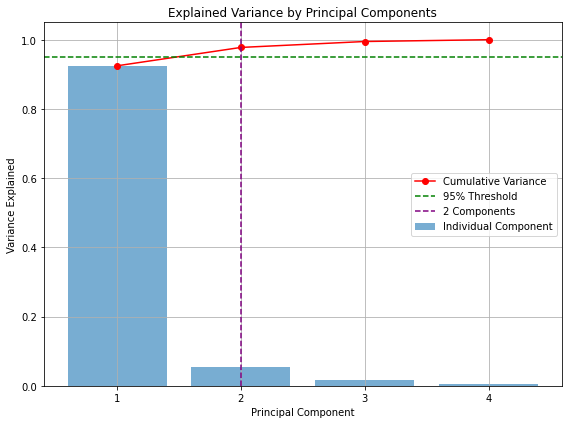

Number of components to retain 95% variance: 2


In [ ]:
# Example to show 95% variance

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# Load dataset
data = load_iris()
X = data.data

# Apply PCA without limiting components
pca = PCA()
X_pca = pca.fit_transform(X)

# Get explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot explained variance
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.6, label='Individual Component')
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', color='red', label='Cumulative Variance')

# Add a horizontal line at 95%
plt.axhline(y=0.95, color='green', linestyle='--', label='95% Threshold')

# Add annotation for number of components needed
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
plt.axvline(x=n_components_95, color='purple', linestyle='--', label=f'{n_components_95} Components')

plt.xticks(range(1, len(explained_variance)+1))
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Explained Variance by Principal Components')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Number of components to retain 95% variance: {n_components_95}")


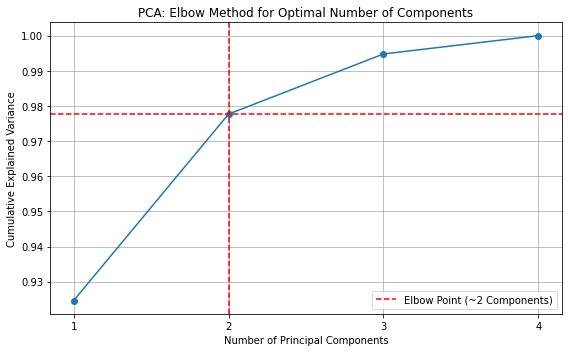

In [ ]:
# Elbow method
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# Load dataset
data = load_iris()
X = data.data

# Fit PCA with all components
pca = PCA()
pca.fit(X)

# Explained variance ratios
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative explained variance (Elbow Method)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.title('PCA: Elbow Method for Optimal Number of Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')

# Highlight the elbow (visually or heuristically)
plt.axvline(x=2, color='red', linestyle='--', label='Elbow Point (~2 Components)')
plt.axhline(y=cumulative_variance[1], color='red', linestyle='--')
plt.grid(True)
plt.xticks(range(1, len(explained_variance)+1))
plt.legend()
plt.tight_layout()
plt.show()


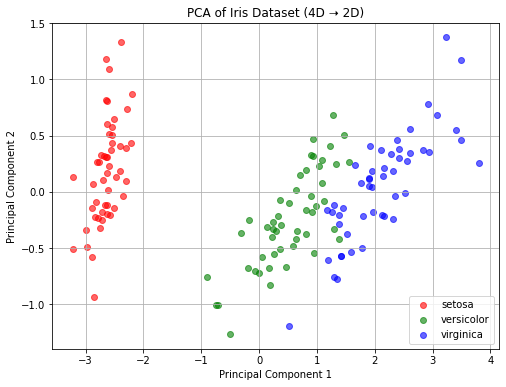

Explained variance ratio: [0.92461872 0.05306648]
Total variance retained: 0.977685206318795


In [ ]:
# Use case
#Visualizing High-Dimensional Data (Iris Dataset)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# Load the Iris dataset
data = load_iris()
X = data.data       # 4D features
y = data.target     # Class labels (0, 1, 2)
target_names = data.target_names

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot the PCA-reduced data
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']

for i, target_name in enumerate(target_names):
    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        label=target_name,
        alpha=0.6,
        color=colors[i]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Iris Dataset (4D ➝ 2D)")
plt.legend()
plt.grid(True)
plt.show()

# Show explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", np.sum(pca.explained_variance_ratio_))


We have just reduced a 4D problem to 2D and still capturing ~95% of the variance.
The figure visually separate the species — which shows how PCA helps discover structure in the data.

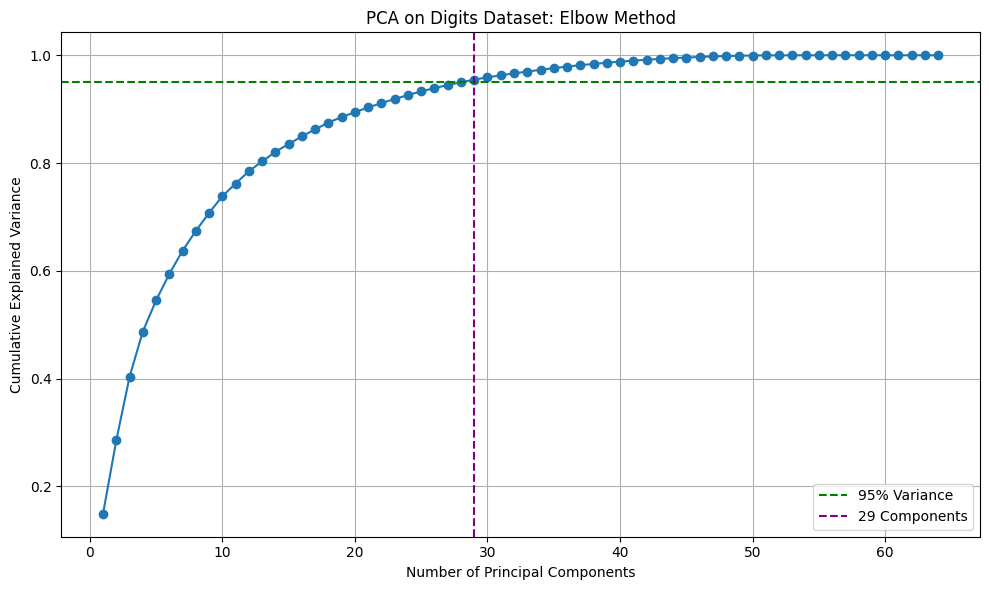

Number of components to retain 95% variance: 29


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# Load high-dimensional dataset
digits = load_digits()
X = digits.data  # Shape (1797, 64)

# Apply PCA with all components
pca = PCA()
pca.fit(X)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
# print(explained_variance,cumulative_variance)

# Plot: Cumulative Explained Variance (Elbow Method)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.title('PCA on Digits Dataset: Elbow Method')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)

# Highlight the 95% threshold
threshold = 0.95
num_components_95 = np.argmax(cumulative_variance >= threshold) + 1
plt.axhline(y=threshold, color='green', linestyle='--', label='95% Variance')
plt.axvline(x=num_components_95, color='purple', linestyle='--', label=f'{num_components_95} Components')

plt.legend()
plt.tight_layout()
plt.show()

# Print result
print(f"Number of components to retain 95% variance: {num_components_95}")


# From 64 features → PCA computes 64 eigenvectors (covariance matrix (64 × 64))
# Out of those: Top 30 eigenvectors capture ~95% variance

# What those 30 actually represent ?
Each of the 30 components is:

A linear combination of the 64 original features

Not a single feature, but something like:
    PC_1=0.2x1+0.5x2-0.1x3+⋯
    
So:
	They are new axes 
	Rotated relative to original feature space

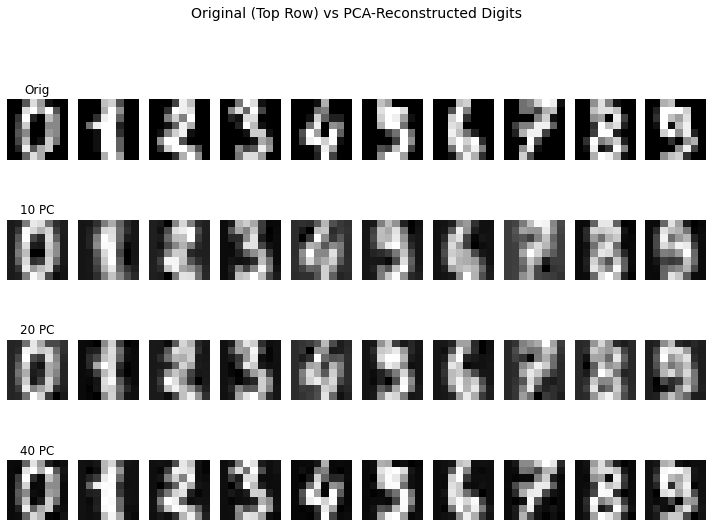

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# Load digit data (1797 samples, 64 features)
digits = load_digits()
X = digits.data
images = digits.images

# Function to plot original vs reconstructed digits
def plot_reconstruction(n_components_list):
    fig, axes = plt.subplots(len(n_components_list), 10, figsize=(10, 2 * len(n_components_list)))
    fig.suptitle("Original (Top Row) vs PCA-Reconstructed Digits", fontsize=14)

    for row, n_components in enumerate(n_components_list):
        pca = PCA(n_components=n_components)
        X_reduced = pca.fit_transform(X)
        X_reconstructed = pca.inverse_transform(X_reduced)

        for i in range(10):
            if row == 0:
                # Top row: original images
                axes[row, i].imshow(images[i], cmap='gray')
                axes[row, i].set_title("Orig" if i == 0 else "")
            else:
                # Reconstructed images
                digit = X_reconstructed[i].reshape(8, 8)
                axes[row, i].imshow(digit, cmap='gray')
                axes[row, i].set_title(f"{n_components} PC" if i == 0 else "")
            axes[row, i].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Show reconstructions using increasing PCA components
plot_reconstruction([64, 10, 20, 40])


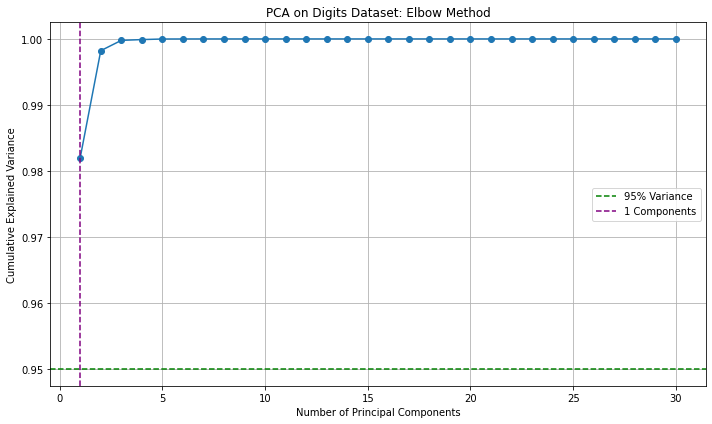

Number of components to retain 95% variance: 1


In [ ]:
# please check and tell us how many PCA components are required.

from sklearn.datasets import load_wine
data = load_wine()
X = data.data
y = data.target


from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
y = data.target


# # Apply PCA with all components
# pca = PCA()
# pca.fit(X)

# # Explained variance
# explained_variance = pca.explained_variance_ratio_
# cumulative_variance = np.cumsum(explained_variance)

# # Plot: Cumulative Explained Variance (Elbow Method)
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
# plt.title('PCA on Digits Dataset: Elbow Method')
# plt.xlabel('Number of Principal Components')
# plt.ylabel('Cumulative Explained Variance')
# plt.grid(True)

# # Highlight the 95% threshold
# threshold = 0.95
# num_components_95 = np.argmax(cumulative_variance >= threshold) + 1
# plt.axhline(y=threshold, color='green', linestyle='--', label='95% Variance')
# plt.axvline(x=num_components_95, color='purple', linestyle='--', label=f'{num_components_95} Components')

# plt.legend()
# plt.tight_layout()
# plt.show()

# # Print result
# print(f"Number of components to retain 95% variance: {num_components_95}")

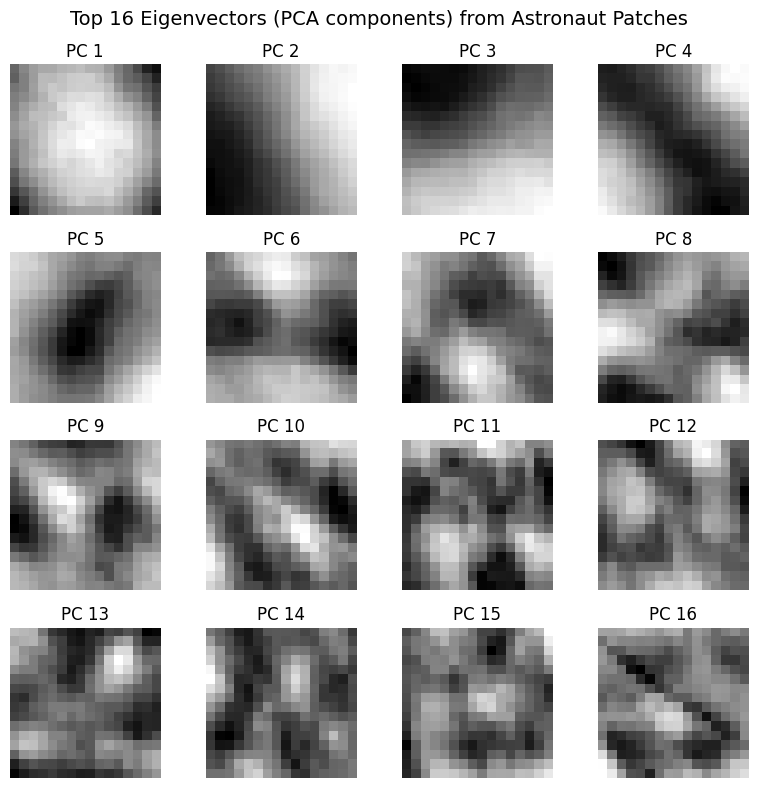

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage.util import view_as_blocks

image = rgb2gray(data.astronaut())
image = image[:256, :256]  # Crop to 256x256 for simplicity

# Extract non-overlapping 16x16 patches
patch_size = (16, 16)
patches = view_as_blocks(image, block_shape=patch_size)

# Reshape patches to (num_patches, patch_height * patch_width)
num_blocks_x, num_blocks_y, _, _ = patches.shape
flattened_patches = patches.reshape(-1, patch_size[0] * patch_size[1])

# Standardize (important before PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(flattened_patches)

# Apply PCA
pca = PCA(n_components=16)  # Let's look at top 16 eigenvectors
pca.fit(X_scaled)

# Visualize eigenvectors (principal components)
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    component = pca.components_[i].reshape(patch_size)
    ax.imshow(component, cmap='gray')
    ax.set_title(f'PC {i+1}')
    ax.axis('off')

plt.suptitle("Top 16 Eigenvectors (PCA components) from Astronaut Patches", fontsize=14)
plt.tight_layout()
plt.show()


1. Each of these 16 images is an eigenvector in image space — a direction of variation.
2. These are like image building blocks.
3. Any image patch can be approximately reconstructed by combining these eigenvectors weighted by their coefficients (principal components).
4. It shows that structure in images lives in a lower-dimensional space

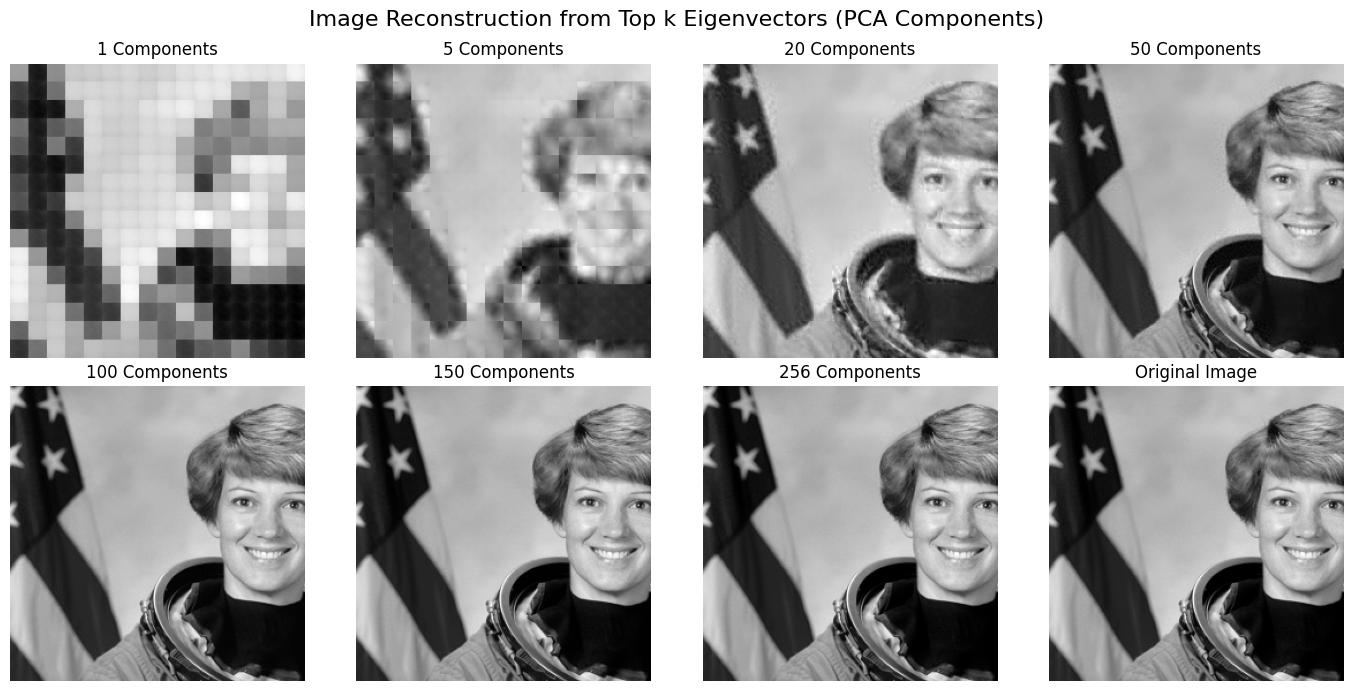

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage.util import view_as_blocks

# Step 1: Load image
image = rgb2gray(data.astronaut())
image = image[:256, :256]  # Crop to square

# Step 2: Extract 16x16 patches
patch_size = (16, 16)
patches = view_as_blocks(image, block_shape=patch_size)
num_blocks_x, num_blocks_y, _, _ = patches.shape
flattened_patches = patches.reshape(-1, patch_size[0] * patch_size[1])

# Step 3: Standardize patches
scaler = StandardScaler()
X_scaled = scaler.fit_transform(flattened_patches)

# Step 4: Apply PCA to learn components
pca = PCA(n_components=256)  # Use all components for now
pca.fit(X_scaled)

# Function to reconstruct image from top k components
def reconstruct_image(k):
    # Project data to top-k components and inverse transform
    X_k = pca.transform(X_scaled)[:, :k]
    X_recon = pca.inverse_transform(
        np.hstack([X_k, np.zeros((X_k.shape[0], pca.n_components_ - k))])
    )
    # Unscale
    X_recon = scaler.inverse_transform(X_recon)
    # Reshape patches back
    recon_patches = X_recon.reshape(num_blocks_x, num_blocks_y, *patch_size)

    # Reconstruct the image manually
    rows = [np.hstack(recon_patches[i, :, :, :]) for i in range(num_blocks_x)]
    reconstructed_image = np.vstack(rows)
    return reconstructed_image

# Step 5: Reconstruct with different numbers of components
ks = [1, 5, 20, 50, 100, 150, 256]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, k in zip(axes.flat[:-1], ks):
    recon = reconstruct_image(k)
    ax.imshow(recon, cmap='gray')
    ax.set_title(f'{k} Components')
    ax.axis('off')

# Show original image
axes.flat[-1].imshow(image, cmap='gray')
axes.flat[-1].set_title('Original Image')
axes.flat[-1].axis('off')

plt.suptitle("Image Reconstruction from Top k Eigenvectors (PCA Components)", fontsize=16)
plt.tight_layout()
plt.show()


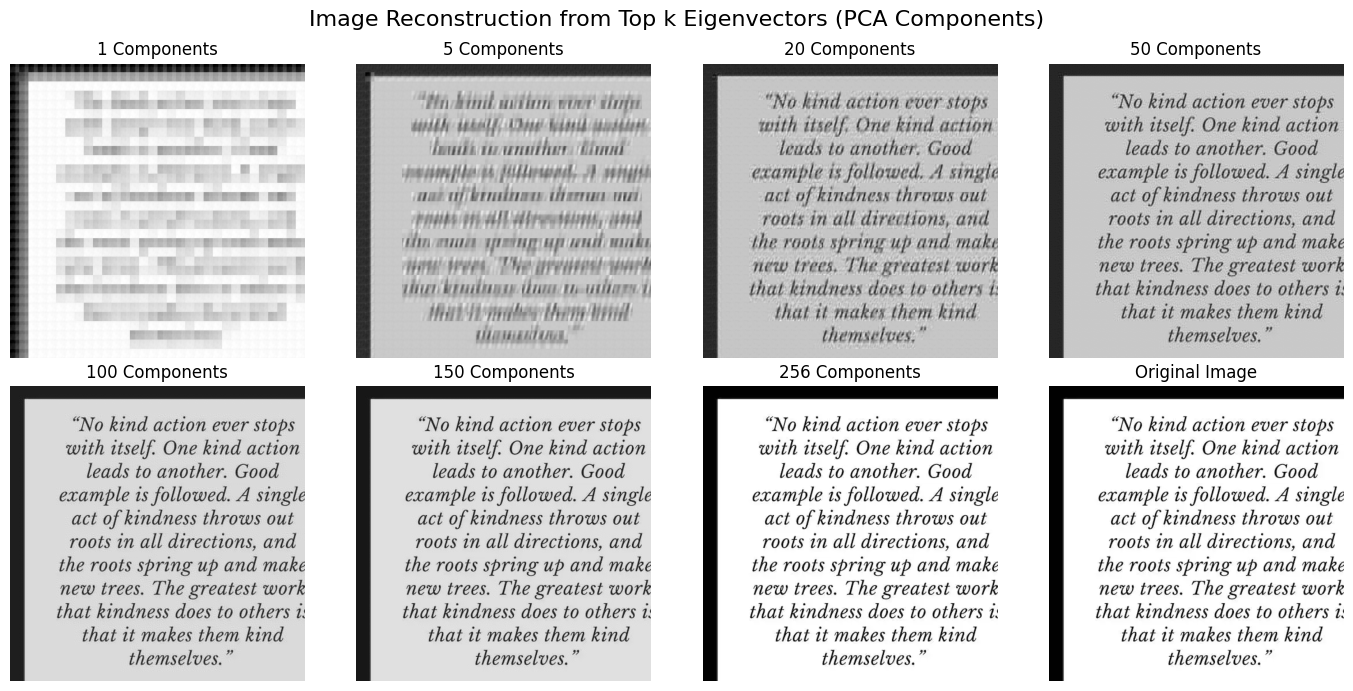

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage.util import view_as_blocks
from skimage import io, color

# Step 1: Load and preprocess your image
image_path = 'kkind.webp'

# Load image and convert it to grayscale
image = io.imread(image_path)
image = color.rgb2gray(image)  # Convert to grayscale (if it's in RGB)

# Optionally, resize to make it smaller (e.g., 256x256)
image = image[:512, :512]  # Crop to 256x256 for simplicity

# Step 2: Extract patches (16x16)
patch_size = (16, 16)
patches = view_as_blocks(image, block_shape=patch_size)
num_blocks_x, num_blocks_y, _, _ = patches.shape
flattened_patches = patches.reshape(-1, patch_size[0] * patch_size[1])

# Step 3: Standardize the patches (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(flattened_patches)

# Step 4: Apply PCA to learn components
pca = PCA(n_components=256)  # Use all components for now
pca.fit(X_scaled)

# Function to reconstruct image from top k components
def reconstruct_image(k):
    # Project data to top-k components and inverse transform
    X_k = pca.transform(X_scaled)[:, :k]
    X_recon = pca.inverse_transform(
        np.hstack([X_k, np.zeros((X_k.shape[0], pca.n_components_ - k))])
    )
    # Unscale
    X_recon = scaler.inverse_transform(X_recon)
    # Reshape patches back
    recon_patches = X_recon.reshape(num_blocks_x, num_blocks_y, *patch_size)

    # Reconstruct the image manually
    rows = [np.hstack(recon_patches[i, :, :, :]) for i in range(num_blocks_x)]
    reconstructed_image = np.vstack(rows)
    return reconstructed_image

# Step 5: Reconstruct with different numbers of components
ks = [1, 5, 20, 50, 100, 150, 256]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, k in zip(axes.flat[:-1], ks):
    recon = reconstruct_image(k)
    ax.imshow(recon, cmap='gray')
    ax.set_title(f'{k} Components')
    ax.axis('off')

# Show original image
axes.flat[-1].imshow(image, cmap='gray')
axes.flat[-1].set_title('Original Image')
axes.flat[-1].axis('off')

plt.suptitle("Image Reconstruction from Top k Eigenvectors (PCA Components)", fontsize=16)
plt.tight_layout()
plt.show()


2025-04-13 09:52:24.480163: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-13 09:52:24.617461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744518144.660380  993787 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744518144.673449  993787 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-13 09:52:24.814094: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 39s 0us/step


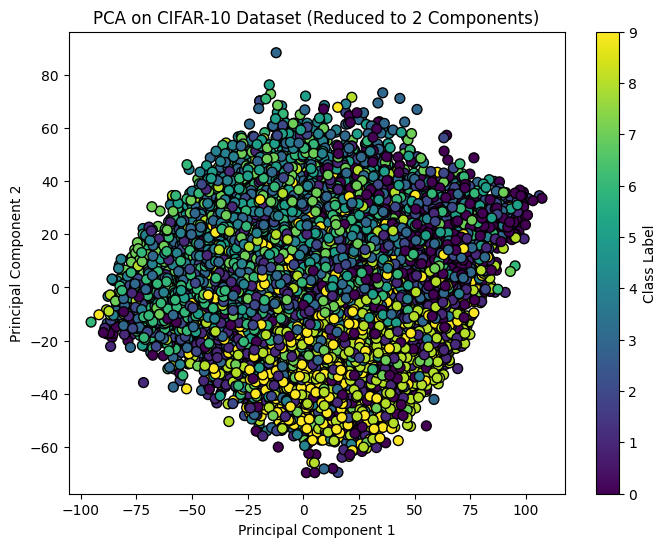

Explained Variance Ratio (PCA components): [0.26920217 0.11370516]
Total variance explained by 2 components: 0.38


In [ ]:
# Another example on large dataset to see how dimensions have been reduced

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Rescaling the images (from 0-255 to 0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the images into vectors (32x32x3 => 3072 features per image)
x_train_flattened = x_train.reshape(x_train.shape[0], -1)
x_test_flattened = x_test.reshape(x_test.shape[0], -1)

# Standardize the data (important for PCA)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flattened)
x_test_scaled = scaler.transform(x_test_flattened)

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
x_train_pca = pca.fit_transform(x_train_scaled)

# Visualize the reduced dataset
plt.figure(figsize=(8, 6))
plt.scatter(x_train_pca[:, 0], x_train_pca[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=50)
plt.colorbar(label='Class Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA on CIFAR-10 Dataset (Reduced to 2 Components)')
plt.show()

# Explained variance
print(f"Explained Variance Ratio (PCA components): {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {np.sum(pca.explained_variance_ratio_):.2f}")


x-axis → PC1 (Principal Component 1)
y-axis → PC2 (Principal Component 2)

What is PC1 and PC2 ?

# Our original data:

Each image = 3072 features (32×32×3 pixels)

After PCA:

Each image becomes just 2 values:
PC1 → first number
PC2 → second number

# So each image is now a point in 2D space

# Meaning of PC1

PC1 = direction capturing the MOST variation in the dataset

In simple terms:

It finds the strongest pattern across all images
For CIFAR-10, this could relate to:
        Overall brightness
        Color distribution
        Dominant shapes/textures

It’s NOT a single feature like “pixel 1”
It’s a combination of all 3072 pixels

# Meaning of PC2

PC2 = second most important pattern (independent of PC1)

Captures variation that PC1 missed
Orthogonal (independent) to PC1

# Think:

PC1 = biggest trend
PC2 = second biggest trend

<!-- 
“Each image originally had 3072 features. PCA compresses it into 2 values—PC1 and PC2—which represent the most important patterns in the data. 
The plot shows where each image lies based on those patterns.” -->

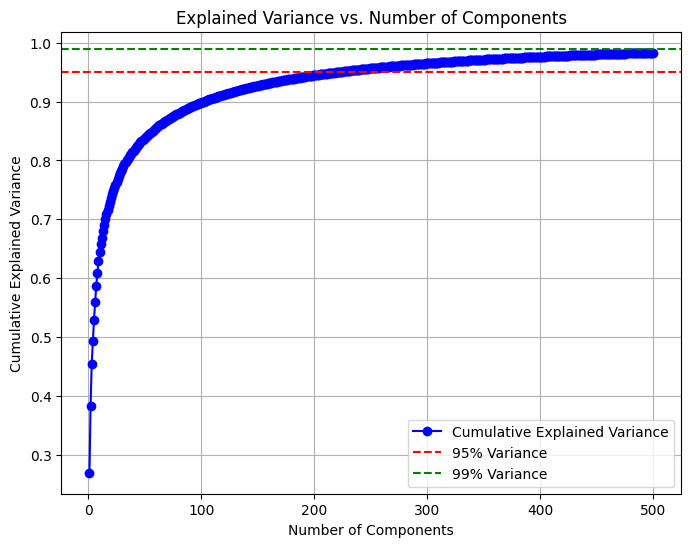

Number of components to explain 95% variance: 220
Number of components to explain 99% variance: 0
Original dataset shape: (50000, 3072)
Reduced dataset shape (after PCA): (50000, 100)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import cifar10
from sklearn.preprocessing import StandardScaler

# Load CIFAR-10 dataset
#(x_train, y_train), (x_test, y_test) = cifar10.load_data()


# Rescale the images (from 0-255 to 0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the images into vectors (32x32x3 => 3072 features per image)
x_train_flattened = x_train.reshape(x_train.shape[0], -1)
x_test_flattened = x_test.reshape(x_test.shape[0], -1)

# Standardize the data (important for PCA)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flattened)
x_test_scaled = scaler.transform(x_test_flattened)

# Apply PCA with a range of components (e.g., 2 to 500 components)
pca = PCA(n_components=500)  # Maximum possible number of components for the data
pca.fit(x_train_scaled)

# Visualize Explained Variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot the explained variance
plt.figure(figsize=(8, 6))
plt.plot(range(1, 501), cumulative_variance, marker='o', color='b', linestyle='-', label='Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.legend()
plt.grid(True)
plt.show()

#Determine the number of components needed to retain 95% or 99% variance
components_95 = np.argmax(cumulative_variance >= 0.95)# + 1
components_99 = np.argmax(cumulative_variance >= 0.99)# + 1

# The +1 is used because the np.argmax function returns the index of the first element in the cumulative variance array
# that exceeds a certain threshold (like 95% or 99%).
# However, the index is zero-based, meaning that if we are interested in the n-th component (where n is 1-based),
# we need to adjust by adding 1

print(f"Number of components to explain 95% variance: {components_95}")
print(f"Number of components to explain 99% variance: {components_99}")

# Apply PCA with reduced number of components (e.g., 100 components)
pca_reduced = PCA(n_components=100)
x_train_pca = pca_reduced.fit_transform(x_train_scaled)

# Visualize the shape of the original and reduced datasets
print(f"Original dataset shape: {x_train_scaled.shape}")
print(f"Reduced dataset shape (after PCA): {x_train_pca.shape}")

PCA is linear, meaning it assumes that the relationships between the features are linear. It works by finding directions (principal components) that maximize the variance, but these directions are linear combinations of the original features.

The principal components are linear combinations of the original features, but they are not always interpretable. In practice, it can be challenging to explain what each principal component represents, especially when dealing with high-dimensional data like images.

PCA assumes that the components with the highest variance are the most important. However, this may not always be the case. For example, a component with high variance might capture noise, while a component with lower variance might contain more meaningful information for your problem.